# Projeto Original — Análise de Sentimentos com Embeddings

**Ciclo de divergência: `MODEL`.**

O projeto FMF resolve a classificação binária de sentimento em reviews do IMDB usando **TF-IDF + algoritmos clássicos de ML**. Aqui mantemos exatamente o mesmo problema, os mesmos dados e o mesmo classificador final, e trocamos apenas a **representação textual** — que é o nosso ponto de divergência.

Comparamos 4 representações, da mais lexical à mais semântica:

1. **TF-IDF** — reproduz o FMF (linha de base).
2. **BM25** — baseline lexical forte (TF-IDF melhorado: saturação de termo + normalização por comprimento).
3. **BGE-large-en-v1.5** — embedding denso especialista em inglês, SOTA, mas trunca em 512 tokens.
4. **BGE-M3** — embedding denso de **contexto longo (8192 tokens)**: lê a review inteira sem truncar.

Todas as representações alimentam os **mesmos classificadores** (SVM linear e Regressão Logística), isolando a variável "representação textual".

> **Pergunta de pesquisa do ciclo:** ler a review inteira (BGE-M3) compensa, ou um encoder inglês mais forte vence mesmo truncando? E os embeddings densos realmente superam um bom método lexical (BM25) num dataset pequeno?

## Dependências

Execute a célula abaixo uma vez para instalar as bibliotecas necessárias (descomente se ainda não tiver instalado).

In [1]:
!pip install pandas scikit-learn imbalanced-learn matplotlib seaborn sentence-transformers torch kagglehub

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
plt.rc('axes', titlesize=18)
plt.rc('axes', labelsize=14)
plt.rc('xtick', labelsize=13)
plt.rc('ytick', labelsize=13)
plt.rc('legend', fontsize=13)
plt.rc('font', size=13)

RANDOM_STATE = 42

# GET — Obtenção dos dados

Usamos o **mesmo dataset do FMF** (IMDB, 50k reviews), mas **ampliamos a amostra**. O FMF usava apenas 2.000 exemplos (1.000 por classe, após undersampling de um grab intencionalmente desbalanceado de 9.000×1.000). Como o dataset completo já é perfeitamente balanceado (**25k positivas / 25k negativas**), montamos diretamente um conjunto balanceado de **10.000 por classe (20.000 no total)** — 10× mais dado — **sem desperdício por undersampling**.

Mantemos o mesmo `random_state` em todas as etapas, então o split treino/teste é reprodutível e qualquer diferença de desempenho continua vindo da representação textual, não dos dados.

> **Obtenção do CSV.** A célula abaixo primeiro procura o `IMDB Dataset.csv` localmente; se não achar, baixa do [Kaggle](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews) via `kagglehub`. No **Google Colab**, crie dois *Secrets* (ícone de chave 🔑 na barra lateral) chamados **`KAGGLE_USERNAME`** e **`KAGGLE_KEY`**, com os valores do seu `kaggle.json` (Kaggle → *Account* → *Create New API Token*), e ative o acesso ao notebook. Fora do Colab, basta ter `~/.kaggle/kaggle.json` ou as variáveis de ambiente `KAGGLE_USERNAME`/`KAGGLE_KEY` definidas. Baixar via Kaggle evita o truncamento que costuma ocorrer no upload manual de arquivos grandes (~66 MB).

In [3]:
import os

# 1) Tenta achar o CSV localmente (execução fora do Colab, com o arquivo já no repositório).
CANDIDATE_PATHS = [
    'IMDB Dataset.csv',
    '../IMDB Dataset.csv',
    '../FMF/IMDB Dataset.csv',
    'FMF/IMDB Dataset.csv',
]
csv_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)

# 2) Se não achou localmente, baixa do Kaggle via kagglehub.
if csv_path is None:
    # No Colab, carrega as credenciais a partir dos Secrets (KAGGLE_USERNAME e KAGGLE_KEY).
    try:
        from google.colab import userdata
        os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
        os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
    except Exception:
        pass  # fora do Colab: usa ~/.kaggle/kaggle.json ou variáveis de ambiente já definidas

    import kagglehub
    dataset_dir = kagglehub.dataset_download('lakshmi25npathi/imdb-dataset-of-50k-movie-reviews')
    csv_path = os.path.join(dataset_dir, 'IMDB Dataset.csv')
    if not os.path.exists(csv_path):  # fallback: pega qualquer .csv do diretório baixado
        import glob
        csv_path = glob.glob(os.path.join(dataset_dir, '*.csv'))[0]

print('Carregado de:', csv_path)
df_review = pd.read_csv(csv_path)

# Sanidade: confirma que o arquivo veio inteiro (50.000 linhas) — pega truncamento de upload.
assert len(df_review) == 50000, f'Esperado 50000 linhas, veio {len(df_review)} — arquivo truncado?'
df_review.head()

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Carregado de: /kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
# Amostragem balanceada ampliada: 10.000 positivos + 10.000 negativos (20.000 no total).
# Substitui o grab desbalanceado 9000x1000 + undersampling do FMF: o IMDB completo já é
# 25k/25k, então há folga de sobra para um conjunto balanceado muito maior que os 2.000
# usados originalmente, sem desperdiçar exemplos via undersampling.
N_PER_CLASS = 10000

# Remove reviews duplicadas (418 no total, todas sem rótulo conflitante) para evitar que a
# mesma review apareça simultaneamente em treino e teste (vazamento).
df_dedup = df_review.drop_duplicates(subset=['review'])

# Amostra balanceada e reprodutível (mesmo RANDOM_STATE do restante do notebook).
df_review_bal = (
    df_dedup.groupby('sentiment', group_keys=False)
    .sample(n=N_PER_CLASS, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)
df_review_bal.value_counts('sentiment')

,count
sentiment,
negative,10000
positive,10000


In [5]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df_review_bal, test_size=0.33, random_state=RANDOM_STATE)
train_x, train_y = train['review'], train['sentiment']
test_x, test_y = test['review'], test['sentiment']

print('Treino:', train_x.shape[0], '| Teste:', test_x.shape[0])
print(train_y.value_counts())

Treino: 13400 | Teste: 6600
sentiment
positive    6729
negative    6671
Name: count, dtype: int64


In [6]:
# Estatística de comprimento das reviews — motiva o uso de modelos de contexto longo
lengths = train_x.str.split().str.len()
print(f'Palavras por review (treino): média={lengths.mean():.0f}, '
      f'mediana={lengths.median():.0f}, p95={lengths.quantile(0.95):.0f}, máx={lengths.max()}')
print(f'% de reviews com >512 palavras: {(lengths > 512).mean() * 100:.1f}%')

Palavras por review (treino): média=231, mediana=174, p95=585, máx=2125
% de reviews com >512 palavras: 7.1%


# Função de avaliação comum

Para uma comparação justa, todas as representações usam o mesmo procedimento: treinar **SVM linear** e **Regressão Logística** sobre os vetores e avaliar com acurácia, F1 e matriz de confusão. Os resultados são acumulados em `RESULTS`.

In [7]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

LABELS = ['positive', 'negative']
RESULTS = []


def evaluate_representation(name, X_train, X_test, y_train=train_y, y_test=test_y, verbose=True):
    """Treina SVM linear e Regressão Logística e registra as métricas."""
    models = {
        'SVM (linear)': SVC(kernel='linear', C=1),
        'LogReg': LogisticRegression(max_iter=1000),
    }
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        f1_pos, f1_neg = f1_score(y_test, pred, labels=LABELS, average=None)
        f1_macro = f1_score(y_test, pred, labels=LABELS, average='macro')
        RESULTS.append({
            'Representação': name,
            'Classificador': model_name,
            'Acurácia': acc,
            'F1 (pos)': f1_pos,
            'F1 (neg)': f1_neg,
            'F1 macro': f1_macro,
        })
        if verbose:
            print(f'\n=== {name} — {model_name} ===')
            print(f'Acurácia: {acc:.4f} | F1 macro: {f1_macro:.4f}')
            print(classification_report(y_test, pred, labels=LABELS))
    return models

# Representação 1 — TF-IDF (reprodução do FMF)

Linha de base: o mesmo `TfidfVectorizer` do projeto FMF.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
tfidf_train = tfidf.fit_transform(train_x)
tfidf_test = tfidf.transform(test_x)
print('Matriz TF-IDF:', tfidf_train.shape)

evaluate_representation('TF-IDF', tfidf_train, tfidf_test)

Matriz TF-IDF: (13400, 58692)

=== TF-IDF — SVM (linear) ===
Acurácia: 0.8756 | F1 macro: 0.8756
              precision    recall  f1-score   support

    positive       0.87      0.88      0.88      3271
    negative       0.88      0.87      0.88      3329

    accuracy                           0.88      6600
   macro avg       0.88      0.88      0.88      6600
weighted avg       0.88      0.88      0.88      6600


=== TF-IDF — LogReg ===
Acurácia: 0.8742 | F1 macro: 0.8742
              precision    recall  f1-score   support

    positive       0.86      0.89      0.87      3271
    negative       0.89      0.86      0.87      3329

    accuracy                           0.87      6600
   macro avg       0.87      0.87      0.87      6600
weighted avg       0.87      0.87      0.87      6600



{'SVM (linear)': SVC(C=1, kernel='linear'),
 'LogReg': LogisticRegression(max_iter=1000)}

# Representação 2 — BM25 (baseline lexical forte)

BM25 é uma evolução do TF-IDF: além da frequência inversa de documento (IDF), aplica **saturação de termo** (com o parâmetro `k1`, frequências altas param de crescer linearmente) e **normalização por comprimento do documento** (com `b`). É o padrão de mercado em busca textual (ex.: Lucene/Elasticsearch).

Como o `scikit-learn` não traz BM25, implementamos um vetorizador BM25 compatível com a API `fit`/`transform`, reaproveitando a contagem de termos do `CountVectorizer`. O resultado é uma matriz esparsa documento-termo pronta para os mesmos classificadores.

In [9]:
import scipy.sparse as sp
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.base import BaseEstimator, TransformerMixin


class BM25Vectorizer(BaseEstimator, TransformerMixin):
    """Vetorizador BM25 (variante Lucene/Okapi com IDF não-negativo).

    Aprende vocabulário, IDF e comprimento médio dos documentos no fit;
    no transform produz a matriz esparsa de pesos BM25 por termo.
    """

    def __init__(self, k1=1.5, b=0.75, stop_words='english'):
        self.k1 = k1
        self.b = b
        self.stop_words = stop_words

    def fit(self, raw_documents, y=None):
        self.cv_ = CountVectorizer(stop_words=self.stop_words)
        tf = self.cv_.fit_transform(raw_documents)            # contagem de termos
        n_docs = tf.shape[0]
        df = np.bincount(tf.indices, minlength=tf.shape[1])    # nº de docs por termo
        # IDF estilo Lucene: sempre >= 0
        self.idf_ = np.log(1 + (n_docs - df + 0.5) / (df + 0.5))
        self.avgdl_ = tf.sum(axis=1).mean()
        return self

    def transform(self, raw_documents):
        tf = self.cv_.transform(raw_documents).tocsr()
        doc_len = np.asarray(tf.sum(axis=1)).ravel()
        tf = tf.tocoo()
        # denominador da fórmula BM25, por elemento não-nulo
        denom = tf.data + self.k1 * (1 - self.b + self.b * doc_len[tf.row] / self.avgdl_)
        scores = self.idf_[tf.col] * (tf.data * (self.k1 + 1)) / denom
        return sp.csr_matrix((scores, (tf.row, tf.col)), shape=tf.shape)

    def get_feature_names_out(self, input_features=None):
        return self.cv_.get_feature_names_out(input_features)

In [10]:
bm25 = BM25Vectorizer()
bm25_train = bm25.fit_transform(train_x)
bm25_test = bm25.transform(test_x)
print('Matriz BM25:', bm25_train.shape)

evaluate_representation('BM25', bm25_train, bm25_test)

Matriz BM25: (13400, 58692)

=== BM25 — SVM (linear) ===
Acurácia: 0.8612 | F1 macro: 0.8612
              precision    recall  f1-score   support

    positive       0.86      0.86      0.86      3271
    negative       0.86      0.86      0.86      3329

    accuracy                           0.86      6600
   macro avg       0.86      0.86      0.86      6600
weighted avg       0.86      0.86      0.86      6600


=== BM25 — LogReg ===
Acurácia: 0.8765 | F1 macro: 0.8765
              precision    recall  f1-score   support

    positive       0.88      0.87      0.88      3271
    negative       0.88      0.88      0.88      3329

    accuracy                           0.88      6600
   macro avg       0.88      0.88      0.88      6600
weighted avg       0.88      0.88      0.88      6600



{'SVM (linear)': SVC(C=1, kernel='linear'),
 'LogReg': LogisticRegression(max_iter=1000)}

# Embeddings densos

A partir daqui trocamos representações esparsas (palavra-a-palavra) por **embeddings densos**: vetores contínuos que capturam significado semântico, gerados por modelos pré-treinados. Carregamos os modelos com `sentence-transformers` e usamos GPU se disponível.

> O download dos modelos (centenas de MB a ~2 GB) ocorre na primeira execução. Em CPU, codificar ~2000 textos leva alguns minutos.

In [11]:
from sentence_transformers import SentenceTransformer
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)


def embed(model_name, texts, **kwargs):
    model = SentenceTransformer(model_name, device=DEVICE)
    emb = model.encode(
        list(texts),
        batch_size=16,
        normalize_embeddings=True,
        show_progress_bar=True,
        convert_to_numpy=True,
        **kwargs,
    )
    del model
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    return emb

Device: cuda


# Representação 3 — BGE-large-en-v1.5

Embedding denso **especialista em inglês**, no topo do MTEB para tarefas de classificação. Janela de contexto de **512 tokens** — reviews mais longas são truncadas, perdendo o final do texto.

In [12]:
bge_train = embed('BAAI/bge-large-en-v1.5', train_x)
bge_test = embed('BAAI/bge-large-en-v1.5', test_x)
print('Embeddings BGE-large-en:', bge_train.shape)

evaluate_representation('BGE-large-en-v1.5', bge_train, bge_test)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/838 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/413 [00:00<?, ?it/s]

Embeddings BGE-large-en: (13400, 1024)

=== BGE-large-en-v1.5 — SVM (linear) ===
Acurácia: 0.9445 | F1 macro: 0.9445
              precision    recall  f1-score   support

    positive       0.94      0.95      0.94      3271
    negative       0.95      0.94      0.94      3329

    accuracy                           0.94      6600
   macro avg       0.94      0.94      0.94      6600
weighted avg       0.94      0.94      0.94      6600


=== BGE-large-en-v1.5 — LogReg ===
Acurácia: 0.9435 | F1 macro: 0.9435
              precision    recall  f1-score   support

    positive       0.94      0.95      0.94      3271
    negative       0.95      0.94      0.94      3329

    accuracy                           0.94      6600
   macro avg       0.94      0.94      0.94      6600
weighted avg       0.94      0.94      0.94      6600



{'SVM (linear)': SVC(C=1, kernel='linear'),
 'LogReg': LogisticRegression(max_iter=1000)}

# Representação 4 — BGE-M3

Embedding denso multilíngue com **contexto longo (8192 tokens)**: consegue ler a review **inteira** sem truncar. Este é o diferencial técnico central do nosso ciclo de divergência.

In [13]:
bgem3_train = embed('BAAI/bge-m3', train_x)
bgem3_test = embed('BAAI/bge-m3', test_x)
print('Embeddings BGE-M3:', bgem3_train.shape)

evaluate_representation('BGE-M3', bgem3_train, bgem3_test)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/838 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/413 [00:00<?, ?it/s]

Embeddings BGE-M3: (13400, 1024)

=== BGE-M3 — SVM (linear) ===
Acurácia: 0.9198 | F1 macro: 0.9198
              precision    recall  f1-score   support

    positive       0.90      0.94      0.92      3271
    negative       0.94      0.90      0.92      3329

    accuracy                           0.92      6600
   macro avg       0.92      0.92      0.92      6600
weighted avg       0.92      0.92      0.92      6600


=== BGE-M3 — LogReg ===
Acurácia: 0.9203 | F1 macro: 0.9203
              precision    recall  f1-score   support

    positive       0.91      0.94      0.92      3271
    negative       0.94      0.90      0.92      3329

    accuracy                           0.92      6600
   macro avg       0.92      0.92      0.92      6600
weighted avg       0.92      0.92      0.92      6600



{'SVM (linear)': SVC(C=1, kernel='linear'),
 'LogReg': LogisticRegression(max_iter=1000)}

# COMMUNICATE — Comparação dos resultados

Consolidamos todas as combinações representação × classificador numa única tabela e gráfico.

In [ ]:
df_results = pd.DataFrame(RESULTS)
df_results = df_results.sort_values('F1 macro', ascending=False).reset_index(drop=True)
df_results.style.format({
    'Acurácia': '{:.3f}', 'F1 (pos)': '{:.3f}', 'F1 (neg)': '{:.3f}', 'F1 macro': '{:.3f}'
}).background_gradient(subset=['F1 macro'], cmap='Greens')

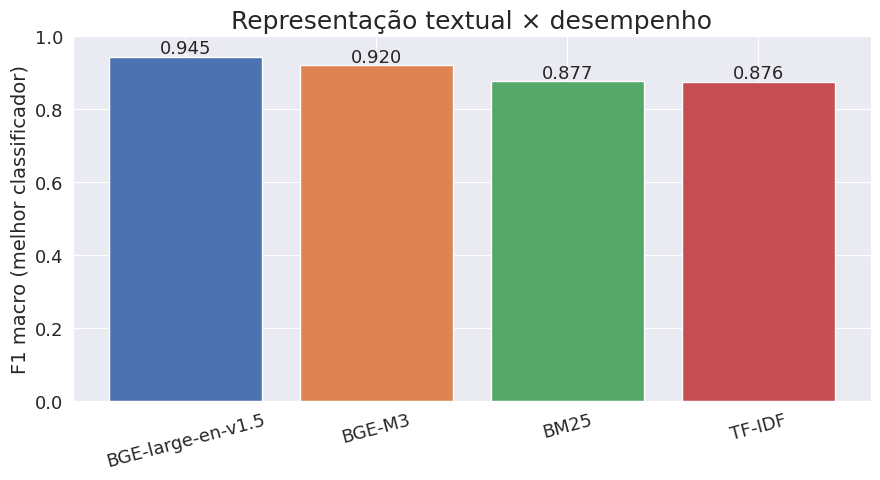

In [16]:
# Melhor classificador por representação
best = df_results.loc[df_results.groupby('Representação')['F1 macro'].idxmax()]
best = best.sort_values('F1 macro', ascending=False)

plt.figure(figsize=(9, 5), tight_layout=True)
colors = sns.color_palette('deep')
bars = plt.bar(best['Representação'], best['F1 macro'], color=colors[:len(best)])
plt.ylabel('F1 macro (melhor classificador)')
plt.title('Representação textual × desempenho')
plt.ylim(0, 1)
plt.xticks(rotation=15)
for bar, val in zip(bars, best['F1 macro']):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f'{val:.3f}', ha='center')
plt.savefig('comparacao_representacoes.png', dpi=120)
plt.show()

## Conclusões

*(Preencher após a execução, com base na tabela e no gráfico acima.)*

Pontos a discutir no relatório:

- **Lexical vs. semântico:** os embeddings densos (BGE) superaram os métodos lexicais (TF-IDF, BM25) neste dataset pequeno (~1.340 exemplos de treino)? Em corpora pequenos é comum que baselines lexicais com SVM linear sejam muito competitivos.
- **BM25 vs. TF-IDF:** a saturação de termo e a normalização por comprimento do BM25 trouxeram ganho sobre o TF-IDF do FMF?
- **Contexto longo (BGE-M3) vs. contexto curto (BGE-large-en):** ler a review inteira compensou, ou o encoder inglês mais forte venceu mesmo truncando em 512 tokens? Relacionar com a % de reviews longas medida na etapa GET.
- **Custo × benefício:** os embeddings exigem download de modelos grandes e mais tempo de inferência. O ganho de desempenho justifica esse custo frente ao TF-IDF/BM25?